[Introduction to Altair](https://deepnote.com/@allan-campopiano/Intro-to-Altair-challenges-with-code-oiylaVDoSXu1a75xovuFRw) - by Allan Campopiano; Plus updates by Mireia Ribera

In [ ]:
# pip install -U altair[all] vega_datasets # uncomment if in desktop

In [1]:
#@title Imported libraries and datasets
import pandas as pd
import altair as alt
import matplotlib.pyplot as plt
from vega_datasets import data

In [2]:
fake_data = pd.DataFrame.from_records([
      {"Beauty": .5, "Number of letters": 3, "img": "https://i.imgur.com/g9A31Tj.png"},
      {"Beauty": 1.5, "Number of letters": 2, "img": "https://i.imgur.com/WZaD8ij.png"},
      {"Beauty": 2.5, "Number of letters": 1, "img": "https://i.imgur.com/DGS7pmg.png"}
])

# Grammar-based data visualization with Altair 📈

Click [here](https://www.youtube.com/watch?v=7sHMlkPklOc) for the  accompanying video tutorial.

## Agenda:

- Overview of visualization libraries in Python
- Declarative visualization (programming paradigms)
- Intro to Grammar of Graphics
- Introduction to Altair
  - marks
  - encodings
  - aggregations
  - compound charts
- Recreate the charts (challenges)


# Visualization libraries in Python
<img src="https://deepnote.com/api/project/a22ca569-50e8-497b-b56b-be71a2fb8547/download-file?path=.%2Fimages%2Feco.png" alt="drawing" width="800"/>

# Visualization and programming paradigms
When thinking of data visualization, consider the following paradigms, especially in terms of how they affect **data exploration**.

**Imperative**:
- specify *how* something should be done
- must manually specify plotting steps
- specification & execution intertwined

**Declarative**:
- specify *what* should be done
- details determined automatically
- separates specification from execution

> **Declarative visualization** lets you think about **data and relationships**, rather than incidental details
>
> Jake VanderPlas ([source](https://medium.com/analytics-vidhya/exploratory-data-visualisation-with-altair-b8d85494795c))

## Example of imperative visualization

In [3]:
df=data.iris()
df

,sepalLength,sepalWidth,petalLength,petalWidth,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


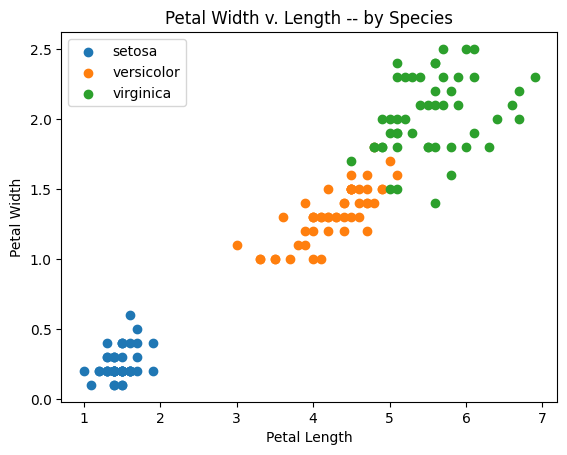

In [4]:
fig, ax = plt.subplots()
colors=['#1f77b4', '#ff7f0e', '#2ca02c']

for color, species in zip(colors, df.species.unique()):
    tmp = df[df.species == species]
    ax.scatter(tmp.petalLength, tmp.petalWidth,
               label=species, color=color)

ax.set(xlabel='Petal Length',
       ylabel='Petal Width',
       title='Petal Width v. Length -- by Species')

ax.legend(loc=2);

☝️ Notice that we are specifying *how* things should be done (make a canvas, loop through this, do that) as well as specifying incidental details (labels, legend position).

## Example of declarative visualization

In [5]:
alt.Chart(df).mark_circle().encode(
    x='petalLength',
    y='petalWidth',
    color='species'
)

alt.Chart(...)

☝️ Notice that we are specifying *what* should be done but not *how* it should be done. That is, we're saying, "Hey Altair, use a circle and map x, y, and color to these columns".

We get the incidental details taken care of for free 😊. This is nice when you want to quickly explore data and not get bogged down having to specify colors, labels, legend details, etc.

In [6]:
# We also can save charts to HTML

chart = alt.Chart(df).mark_circle().encode(
    x='petalLength',
    y='petalWidth',
    color='species'
)

chart.save("chart.html")

# Grammar of Graphics
|   |   |  |
|:---:|:---:|:---:|
![alt](https://images-na.ssl-images-amazon.com/images/I/41T80eRz+aL._SX313_BO1,204,203,200_.jpg) | &nbsp; &nbsp; &nbsp; TL;DR 👉 | ![alt text](https://deepnote.com/api/project/a22ca569-50e8-497b-b56b-be71a2fb8547/download-file?path=images%2Fggal.png)


- a common language for specifying how to map raw data to visual properties on a chart
- thinking about charts as simply a composition of geometric shapes and visual encodings (size, shape, color, position, etc...)
- can lead to consise/expressive code since many charts share a common grammar
- in contrast to charts as being class-based can lead to verbose and bloated programs

### Grammar == consistency

In [7]:
alt.Chart(df).mark_circle().encode(
    x='petalLength',
    y='petalWidth',
    opacity='species'
)

alt.Chart(...)

In [9]:
chart = alt.Chart(df).mark_circle().encode(
    x='petalLength',
    y='petalWidth',
    color='species'
)

chart.save("example.html")

In [10]:
alt.Chart(df).mark_bar().encode(
    x='mean(petalLength)',
    y='species',
    color='species'
)

alt.Chart(...)

# Altair

> With Altair, you can spend more time understanding your data and its meaning. Altair’s API is simple, friendly, and consistent, and built on top of the powerful Vega-Lite visualization grammar. This elegant simplicity produces beautiful and effective visualizations with a minimal amount of code

> Jake Vanderplas

<br>


> It’s this type of 1:1:1 mapping between thinking, code, and visualization that is my favorite thing about the library
>
> Dan Saber
    
![alt](https://deepnote.com/api/project/a22ca569-50e8-497b-b56b-be71a2fb8547/download-file?path=images%2Falt.png)


And check out this great video from Jeffrey Heer about the [future of data visualization](https://www.youtube.com/watch?v=vc1bq0qIKoA)


# Pseudo Altair code
If you want to make a chart, here's a little pseudo code to make the translation into code a bit easier. It's a "grammar" way of thinking.

***

I want to use a <font color="green">circle</font> as my geometric shape

I want to encode...
- <font color="green">petalLength</font> on the X axis
- <font color="green">petalWidth</font> on the Y axis

## Code:

```python
alt.Chart(df).mark_circle().encode(
    x='petalLength',
    y='petalWidth'
)

```

## Notice the form of the code:
- the *Chart* object takes in the data (df)
- the *mark* type specifies the geometric shape we want in our chart
- the *encoding* object specifies the mapping between columns in our data and visual aspects of the chart

## All *simple* Altair charts are specified in this way
 - For a given dataset, specify the mark type and encoding

In [11]:
alt.Chart(df).mark_line().encode(
    x='petalLength',
    y='petalWidth'
)

alt.Chart(...)

# Mark types

<details>
  <summary>Click to expand!</summary>
  <li>mark_bar</li>
  <li>mark_area</li>
  <li>mark_circle</li>
  <li>mark_geoshape</li>
  <li>mark_image</li>
  <li>mark_line</li>
  <li>mark_point</li>
  <li>mark_rect</li>
  <li>mark_rule</li>
  <li>mark_square</li>
  <li>mark_text</li>
  <li>mark_tick</li>
  <li>mark_trail</li>
</details>

<p>

  Also, there are compound marks:
  - mark_boxplot
  - mark_errorband
  - mark_errorbar


... more info about marks [here](https://altair-viz.github.io/user_guide/marks/index.html)

## Example of the **image** mark
- Disclaimer: this chart is just for fun and doesn't reflect actual research

In [ ]:
alt.Chart(fake_data).mark_image(width=50).encode(
    x='Beauty',
    y='Number of letters:N',
    url='img'
).properties(title="Notebook logo metrics")

alt.Chart(...)

# Encodings  
Encodings specify the mapping between columns in your data frame to the visual aspects of your chart. In this workshop, we'll mainly be looking at the following encodings:

## Position encodings
These map the data to coordinates in space.

<details>
  <summary>Click to expand</summary>
<li>x, y</li>
<li>x2, y2</li>
<li>longitude, latitude</li>
<li>longitude2, latitude2,</li>
<li>xError</li>
<li>yError</li>
<li>xError2</li>
<li>yError2</li>
</details>

## Mark encodings
These map the data onto properties of the mark itself.

<details>
  <summary>Click to expand</summary>
<li>color</li>
<li>fill</li>
<li>fillopacity</li>
<li>opacity</li>
<li>shape</li>
<li>size</li>
<li>stroke</li>
<li>strokeDash</li>
<li>strokeOpacity</li>
<li>strokeWidth</li>
</details>

## Text and tooltip
- text
- tooltip

## Facet encodings
These map the data onto views of the data seprated into sub charts.

- row
- column
- facet

There are even more encoding channels. See [here](https://altair-viz.github.io/user_guide/encodings/index.html) for the rest.

## Examples of encoding
I'll demonstrate changing some of the encoding channels below so we can examine their effect on the chart

In [ ]:
alt.Chart(df).mark_point().encode(
    x='petalWidth',
    y='petalLength',
    opacity='species' # color='species' or shape, opacity, color, tooltip, size
)

alt.Chart(...)

# Encoding data types
Altair can do a good job at guessing the data types of your columns; however, sometimes you want to force it to use a particular data type. This can be done by using these letters:

- O is used for ordinal data
- N is used for nominal data
- T is used for temporal data
- Q is used for quantitative data
- G is used for geographic shape

Changing the data type can lead to important differences in how Altair displays the chart. For example:

In [ ]:
cars=data.cars()

alt.Chart(cars).mark_circle().encode(
    x='Horsepower',
    y='Miles_per_Gallon',
    color='Cylinders:N' #O, N, Q
)

alt.Chart(...)

# Aggregation
You've seen some examples of this already but Altair supports many common aggregations. For example:

<details>
  <summary>Click to expand</summary>
<li>count</li>
<li>mean</li>
<li>max</li>
<li>median</li>
<li>min</li>
<li>missing</li>
<li>q1, q3</li>
<li>ci0, ci1,</li>
<li>stderr, stdev,</li>
<li>sum</li>
<li>variance</li>
<li>...and more</li>

</details>

<p>

## Also see [vega lite's time units](https://vega.github.io/vega-lite/docs/timeunit.html)
These work like aggregations and help to collapse datetime objects by various time units

- year
- yearmonth
- yearmonthday
- quarter
- etc..

## Examples of aggregation

In [ ]:
alt.Chart(df).mark_bar().encode(
    x='mean(petalWidth)', #mean, sum, max, mean, variance, ci0, etc...
    y='species',
    color='species'
)

alt.Chart(...)

## Example of time units

In [ ]:
stocks=data.stocks()
stocks

,symbol,date,price
0,MSFT,2000-01-01,39.81
1,MSFT,2000-02-01,36.35
2,MSFT,2000-03-01,43.22
3,MSFT,2000-04-01,28.37
4,MSFT,2000-05-01,25.45
...,...,...,...
555,AAPL,2009-11-01,199.91
556,AAPL,2009-12-01,210.73
557,AAPL,2010-01-01,192.06
558,AAPL,2010-02-01,204.62


In [ ]:
alt.Chart(stocks).mark_line().encode(
    x='yearmonth(date)', #month, year, quarter, yearmonth
    y='mean(price)',
    color='symbol'
)

alt.Chart(...)

# Compound charts
In Altair you can easily layer and concatenate charts.

- \+ operator for layering
- | operator for concatenation

## Examples of compound charts

In [ ]:
bar=alt.Chart(df).mark_bar().encode(
    x='mean(petalWidth)',
    y='species',
    color='species'
)

point=alt.Chart(df).mark_point().encode(
    x='petalWidth',
    y='petalLength',
    color='species'
)

point & bar # |  &


alt.VConcatChart(...)

In [ ]:
bar=alt.Chart(df).mark_bar().encode(
    x='mean(petalWidth)',
    y='species',
    color='species'
)

mean=alt.Chart(df).mark_rule().encode(
    x='mean(petalWidth)',
)

bar + mean

alt.LayerChart(...)

In [ ]:
# You can use the plus operator or the layer

bar=alt.Chart(df).mark_bar().encode(
    x='mean(petalWidth)',
    y='species',
    color='species'
)

mean=alt.Chart(df).mark_rule().encode(
    x='mean(petalWidth)',
)

alt.layer(
    bar,
    mean
)

alt.LayerChart(...)

In [ ]:
circle=alt.Chart(df).mark_circle(size=400).encode(
    x='mean(petalWidth)',
    y='mean(petalLength)',
    color='species'
)

point=alt.Chart(df).mark_point().encode(
    x='petalWidth',
    y='petalLength',
    color='species'
)

point + circle

alt.LayerChart(...)

# Altair's shorthand vs longhand
Up to now, you've seen Altair has a shorthand way to specify charts. This makes data exploration really fast for simple charts.

However, as your chart gets more detailed, you need to switch to a longer form of the API. It's still pretty expressive though. For example, each encoding channel has it's own class and this allows for various propoerties to be set (ranges, axis labels, etc)

## Example of Altair using the longer form of the API
Necessary for setting properties of the encoding channels

In [ ]:
alt.Chart(df).mark_circle().encode(
    x=alt.X('petalLength'),
    y=alt.Y('petalWidth')
)

alt.Chart(...)

In [ ]:
alt.Chart(df).mark_circle().encode(
    x=alt.X('petalLength').scale(domain=[-4,10]),
    y=alt.Y('petalWidth').axis(labelColor='red'),
    color=alt.Color('species').legend(labelColor='blue')
)

alt.Chart(...)

# Other properties
Altair let's you control MANY properties of a chart. The best way to discover and learn about properties is simply to read the docs. They're documented very well, especially in the Vega-lite docs. For example, click [here](https://vega.github.io/vega-lite/docs/axis.html) to read about axis properties.

Here, I've changed various colors as well as the chart size.

In [ ]:
alt.Chart(df,title="Long form of API & adjusted properties").mark_point(filled=True, color='green', size=90).encode(
    x=alt.X('petalLength').axis(labelColor='red'),
    y=alt.Y('petalWidth').axis(labelColor='blue'),
    shape=alt.Shape('species').legend(labelColor='grey')
).properties(
    width=600,
    height=400
)

alt.Chart(...)

# Binning
I should take a second now to show an example of binning. This is a pretty common operation so let's take a look.

In [ ]:
alt.Chart(df).mark_bar().encode(
    x=alt.X('sepalLength').bin(maxbins=25), # True   maxbins=25
    y='count()'
)

alt.Chart(...)

In [ ]:
alt.Chart(df).mark_rect().encode(
    x=alt.X('sepalLength').bin(True), #bin=alt.Bin(maxbins=25)
    y=alt.X('sepalWidth').bin(True),
    color='count()'
)

alt.Chart(...)

# Recreate the charts!!

**Instructions:**
- You will see a series of charts and their respective datasets below
- The goal is to recreate the chart by writing the correct code
    - Beginner challenges
        - shorthand only
        - simple marks and encodings
        - simple aggregations
    - 10 intermediate
        - multiple encodings
        - more complext marks
        - more complex aggregations
    - 10 expert
        - complete insanity 😉
        - layers and concatenation
        - text mark
        - binning
        - more properties


**Charts will not contain transforms, interactions, or widgets**

## Challenge #1
Beginner

In [12]:
iowa_1=data.iowa_electricity()
iowa_1

,year,source,net_generation
0,2001-01-01,Fossil Fuels,35361
1,2002-01-01,Fossil Fuels,35991
2,2003-01-01,Fossil Fuels,36234
3,2004-01-01,Fossil Fuels,36205
4,2005-01-01,Fossil Fuels,36883
5,2006-01-01,Fossil Fuels,37014
6,2007-01-01,Fossil Fuels,41389
7,2008-01-01,Fossil Fuels,42734
8,2009-01-01,Fossil Fuels,38620
9,2010-01-01,Fossil Fuels,42750


In [ ]:
#@title Challenge1 solution
alt.Chart(iowa_1).mark_line().encode(
    x='year',
    y='mean(net_generation)',
)

alt.Chart(...)

# Challenge #2
Beginner

In [ ]:
iowa_2=data.iowa_electricity()
iowa_2

,year,source,net_generation
0,2001-01-01,Fossil Fuels,35361
1,2002-01-01,Fossil Fuels,35991
2,2003-01-01,Fossil Fuels,36234
3,2004-01-01,Fossil Fuels,36205
4,2005-01-01,Fossil Fuels,36883
5,2006-01-01,Fossil Fuels,37014
6,2007-01-01,Fossil Fuels,41389
7,2008-01-01,Fossil Fuels,42734
8,2009-01-01,Fossil Fuels,38620
9,2010-01-01,Fossil Fuels,42750


In [ ]:
#@title Challenge2 solution
alt.Chart(iowa_2).mark_line().encode(
    x='year',
    y='net_generation',
    color='source'
)

# iowa_2

alt.Chart(...)

# Challenge #3

Beginner

In [ ]:
cars_1=data.cars()
cars_1

,Name,Miles_per_Gallon,Cylinders,Displacement,Horsepower,Weight_in_lbs,Acceleration,Year,Origin
0,chevrolet chevelle malibu,18.0,8,307.0,130.0,3504,12.0,1970-01-01,USA
1,buick skylark 320,15.0,8,350.0,165.0,3693,11.5,1970-01-01,USA
2,plymouth satellite,18.0,8,318.0,150.0,3436,11.0,1970-01-01,USA
3,amc rebel sst,16.0,8,304.0,150.0,3433,12.0,1970-01-01,USA
4,ford torino,17.0,8,302.0,140.0,3449,10.5,1970-01-01,USA
...,...,...,...,...,...,...,...,...,...
401,ford mustang gl,27.0,4,140.0,86.0,2790,15.6,1982-01-01,USA
402,vw pickup,44.0,4,97.0,52.0,2130,24.6,1982-01-01,Europe
403,dodge rampage,32.0,4,135.0,84.0,2295,11.6,1982-01-01,USA
404,ford ranger,28.0,4,120.0,79.0,2625,18.6,1982-01-01,USA


In [ ]:
#@title Challenge3 solution
alt.Chart(cars_1).mark_circle().encode(
    x='Horsepower',
    y='Miles_per_Gallon',
) # cars_1

alt.Chart(...)

# Challenge #4

Beginner

In [ ]:
cars_2=data.cars()
cars_2

,Name,Miles_per_Gallon,Cylinders,Displacement,Horsepower,Weight_in_lbs,Acceleration,Year,Origin
0,chevrolet chevelle malibu,18.0,8,307.0,130.0,3504,12.0,1970-01-01,USA
1,buick skylark 320,15.0,8,350.0,165.0,3693,11.5,1970-01-01,USA
2,plymouth satellite,18.0,8,318.0,150.0,3436,11.0,1970-01-01,USA
3,amc rebel sst,16.0,8,304.0,150.0,3433,12.0,1970-01-01,USA
4,ford torino,17.0,8,302.0,140.0,3449,10.5,1970-01-01,USA
...,...,...,...,...,...,...,...,...,...
401,ford mustang gl,27.0,4,140.0,86.0,2790,15.6,1982-01-01,USA
402,vw pickup,44.0,4,97.0,52.0,2130,24.6,1982-01-01,Europe
403,dodge rampage,32.0,4,135.0,84.0,2295,11.6,1982-01-01,USA
404,ford ranger,28.0,4,120.0,79.0,2625,18.6,1982-01-01,USA


In [ ]:
#@title Challenge4 solution
alt.Chart(cars_2).mark_circle().encode(
    x='Horsepower',
    y='Miles_per_Gallon',
    color='Origin'
)

alt.Chart(...)

# Challenge #5
Beginner

In [ ]:
cars_3=data.cars()
cars_3

,Name,Miles_per_Gallon,Cylinders,Displacement,Horsepower,Weight_in_lbs,Acceleration,Year,Origin
0,chevrolet chevelle malibu,18.0,8,307.0,130.0,3504,12.0,1970-01-01,USA
1,buick skylark 320,15.0,8,350.0,165.0,3693,11.5,1970-01-01,USA
2,plymouth satellite,18.0,8,318.0,150.0,3436,11.0,1970-01-01,USA
3,amc rebel sst,16.0,8,304.0,150.0,3433,12.0,1970-01-01,USA
4,ford torino,17.0,8,302.0,140.0,3449,10.5,1970-01-01,USA
...,...,...,...,...,...,...,...,...,...
401,ford mustang gl,27.0,4,140.0,86.0,2790,15.6,1982-01-01,USA
402,vw pickup,44.0,4,97.0,52.0,2130,24.6,1982-01-01,Europe
403,dodge rampage,32.0,4,135.0,84.0,2295,11.6,1982-01-01,USA
404,ford ranger,28.0,4,120.0,79.0,2625,18.6,1982-01-01,USA


In [ ]:
#@title Challenge5 solution
alt.Chart(cars_3).mark_line().encode(
    x='Year',
    y='mean(Miles_per_Gallon)',
)

alt.Chart(...)

# Challenge #6
Beginner

In [ ]:
cars_4=data.cars()
cars_4

,Name,Miles_per_Gallon,Cylinders,Displacement,Horsepower,Weight_in_lbs,Acceleration,Year,Origin
0,chevrolet chevelle malibu,18.0,8,307.0,130.0,3504,12.0,1970-01-01,USA
1,buick skylark 320,15.0,8,350.0,165.0,3693,11.5,1970-01-01,USA
2,plymouth satellite,18.0,8,318.0,150.0,3436,11.0,1970-01-01,USA
3,amc rebel sst,16.0,8,304.0,150.0,3433,12.0,1970-01-01,USA
4,ford torino,17.0,8,302.0,140.0,3449,10.5,1970-01-01,USA
...,...,...,...,...,...,...,...,...,...
401,ford mustang gl,27.0,4,140.0,86.0,2790,15.6,1982-01-01,USA
402,vw pickup,44.0,4,97.0,52.0,2130,24.6,1982-01-01,Europe
403,dodge rampage,32.0,4,135.0,84.0,2295,11.6,1982-01-01,USA
404,ford ranger,28.0,4,120.0,79.0,2625,18.6,1982-01-01,USA


In [ ]:
#@title Challenge6 solution
alt.Chart(cars_4).mark_line().encode(
    x='Year',
    y='mean(Miles_per_Gallon)',
    color='Origin'
)

alt.Chart(...)

# Challenge #7

Beginner

In [ ]:
barley_1=data.barley()
barley_1

,yield,variety,year,site
0,27.00000,Manchuria,1931,University Farm
1,48.86667,Manchuria,1931,Waseca
2,27.43334,Manchuria,1931,Morris
3,39.93333,Manchuria,1931,Crookston
4,32.96667,Manchuria,1931,Grand Rapids
...,...,...,...,...
115,58.16667,Wisconsin No. 38,1932,Waseca
116,47.16667,Wisconsin No. 38,1932,Morris
117,35.90000,Wisconsin No. 38,1932,Crookston
118,20.66667,Wisconsin No. 38,1932,Grand Rapids


In [ ]:
#@title Challenge7 solution
alt.Chart(barley_1).mark_bar().encode(
    x='sum(yield)',
    y='variety',
    color='site',
)

alt.Chart(...)

# Challenge #8
Beginner

In [ ]:
iowa_3=data.iowa_electricity()
iowa_3

,year,source,net_generation
0,2001-01-01,Fossil Fuels,35361
1,2002-01-01,Fossil Fuels,35991
2,2003-01-01,Fossil Fuels,36234
3,2004-01-01,Fossil Fuels,36205
4,2005-01-01,Fossil Fuels,36883
5,2006-01-01,Fossil Fuels,37014
6,2007-01-01,Fossil Fuels,41389
7,2008-01-01,Fossil Fuels,42734
8,2009-01-01,Fossil Fuels,38620
9,2010-01-01,Fossil Fuels,42750


In [ ]:
#@title Challenge8 solution
alt.Chart(iowa_3).mark_area().encode(
    x='year',
    y='net_generation',
    color='source',
)

alt.Chart(...)

# Challenge #9
Beginner

In [ ]:
birds_1=data.birdstrikes().sample(500, random_state=42)
birds_1

,Airport__Name,Aircraft__Make_Model,Effect__Amount_of_damage,Flight_Date,Aircraft__Airline_Operator,Origin_State,When__Phase_of_flight,Wildlife__Size,Wildlife__Species,When__Time_of_day,Cost__Other,Cost__Repair,Cost__Total_$,Speed_IAS_in_knots
6252,ORLANDO INTL,MD-82,Medium,12/15/98 0:00,US AIRWAYS*,Florida,Approach,Large,Turkey vulture,Day,0,0,0,160.0
4684,NASHVILLE INTL,FOKKER F28 MK 1000,None,4/28/97 0:00,AMERICAN AIRLINES,Tennessee,Landing Roll,Medium,Unknown bird - medium,Day,0,0,0,120.0
1731,AUSTIN-BERGSTROM INTL,MD-80,None,3/10/93 0:00,AMERICAN AIRLINES,Texas,Climb,Small,Unknown bird - small,Day,0,0,0,145.0
4742,KANSAS CITY INTL,B-727-200,None,5/19/97 0:00,AMERICAN AIRLINES,Missouri,Landing Roll,Small,Mourning dove,Day,0,0,0,120.0
4521,SALT LAKE CITY INTL,B-757-200,None,1/14/97 0:00,DELTA AIR LINES,Utah,Landing Roll,Small,Unknown bird - small,Day,0,0,0,135.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5170,ATLANTA INTL,B-767-200,None,10/11/97 0:00,DELTA AIR LINES,Georgia,Descent,Medium,Unknown bird - medium,Day,0,0,0,280.0
7205,SAN FRANCISCO INTL ARPT,B-767-200,None,12/26/99 0:00,AMERICAN AIRLINES,California,Approach,Small,Unknown bird - small,Night,0,0,0,145.0
2522,SEATTLE-TACOMA INTL,MD-80,None,5/11/94 0:00,ALASKA AIRLINES,Washington,Approach,Medium,Unknown bird - medium,Night,0,0,0,205.0
2215,CHICAGO O'HARE INTL ARPT,ATR-72,None,9/29/93 0:00,AMERICAN AIRLINES,Illinois,Approach,Large,Unknown bird - large,Day,0,0,0,100.0


In [ ]:
#@title Challenge9 solution
alt.Chart(birds_1).mark_rect().encode(
    x='When__Phase_of_flight',
    y='Wildlife__Size',
    color='count()'
)

alt.Chart(...)

# Challenge #10
Beginner

In [ ]:
crimea_1=data.crimea()
crimea_1

,date,wounds,other,disease
0,1854-04-01,0,110,110
1,1854-05-01,0,95,105
2,1854-06-01,0,40,95
3,1854-07-01,0,140,520
4,1854-08-01,20,150,800
5,1854-09-01,220,230,740
6,1854-10-01,305,310,600
7,1854-11-01,480,290,820
8,1854-12-01,295,310,1100
9,1855-01-01,230,460,1440


In [ ]:
#@title Challenge10 solution
alt.Chart(crimea_1).mark_trail().encode(
    x='date',
    y='disease',
    size='disease'
)

alt.Chart(...)

# Challenge #11
Intermediate

In [ ]:
weather_1=data.seattle_temps().sample(1000, random_state=42)
weather_1

,date,temp
6055,2010-09-10 08:00:00,57.8
5556,2010-08-20 13:00:00,71.8
8148,2010-12-06 13:00:00,44.6
7945,2010-11-28 02:00:00,40.6
3319,2010-05-19 08:00:00,53.5
...,...,...
1071,2010-02-14 15:00:00,47.7
2968,2010-05-04 17:00:00,58.5
2436,2010-04-12 13:00:00,54.4
6142,2010-09-13 23:00:00,58.1


In [ ]:
#@title Challenge11 solution
alt.Chart(weather_1).mark_line().encode(
    x='month(date):T',
    y='mean(temp)',
)

alt.Chart(...)

# Challenge #12
Intermediate

In [ ]:
cars_5 = data.cars()
cars_5

,Name,Miles_per_Gallon,Cylinders,Displacement,Horsepower,Weight_in_lbs,Acceleration,Year,Origin
0,chevrolet chevelle malibu,18.0,8,307.0,130.0,3504,12.0,1970-01-01,USA
1,buick skylark 320,15.0,8,350.0,165.0,3693,11.5,1970-01-01,USA
2,plymouth satellite,18.0,8,318.0,150.0,3436,11.0,1970-01-01,USA
3,amc rebel sst,16.0,8,304.0,150.0,3433,12.0,1970-01-01,USA
4,ford torino,17.0,8,302.0,140.0,3449,10.5,1970-01-01,USA
...,...,...,...,...,...,...,...,...,...
401,ford mustang gl,27.0,4,140.0,86.0,2790,15.6,1982-01-01,USA
402,vw pickup,44.0,4,97.0,52.0,2130,24.6,1982-01-01,Europe
403,dodge rampage,32.0,4,135.0,84.0,2295,11.6,1982-01-01,USA
404,ford ranger,28.0,4,120.0,79.0,2625,18.6,1982-01-01,USA


In [ ]:
#@title Challenge12 solution
alt.Chart(cars_5).mark_point().encode(
    x='Miles_per_Gallon',
    y='Horsepower',
    color='Cylinders:O',
    shape='Origin'
)

alt.Chart(...)

# Challenge #13
Intermediate

In [ ]:
birds_2= data.birdstrikes().sample(1000, random_state=42)
birds_2

,Airport__Name,Aircraft__Make_Model,Effect__Amount_of_damage,Flight_Date,Aircraft__Airline_Operator,Origin_State,When__Phase_of_flight,Wildlife__Size,Wildlife__Species,When__Time_of_day,Cost__Other,Cost__Repair,Cost__Total_$,Speed_IAS_in_knots
6252,ORLANDO INTL,MD-82,Medium,12/15/98 0:00,US AIRWAYS*,Florida,Approach,Large,Turkey vulture,Day,0,0,0,160.0
4684,NASHVILLE INTL,FOKKER F28 MK 1000,None,4/28/97 0:00,AMERICAN AIRLINES,Tennessee,Landing Roll,Medium,Unknown bird - medium,Day,0,0,0,120.0
1731,AUSTIN-BERGSTROM INTL,MD-80,None,3/10/93 0:00,AMERICAN AIRLINES,Texas,Climb,Small,Unknown bird - small,Day,0,0,0,145.0
4742,KANSAS CITY INTL,B-727-200,None,5/19/97 0:00,AMERICAN AIRLINES,Missouri,Landing Roll,Small,Mourning dove,Day,0,0,0,120.0
4521,SALT LAKE CITY INTL,B-757-200,None,1/14/97 0:00,DELTA AIR LINES,Utah,Landing Roll,Small,Unknown bird - small,Day,0,0,0,135.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3921,AUSTIN-BERGSTROM INTL,MD-82,None,5/14/96 0:00,AMERICAN AIRLINES,Texas,Approach,Small,Unknown bird - small,Night,0,0,0,200.0
6685,KANSAS CITY INTL,B-737-200,None,8/1/99 0:00,DELTA AIR LINES,Missouri,Landing Roll,Small,Unknown bird - small,Day,0,0,0,135.0
3194,DALLAS/FORT WORTH INTL ARPT,MD-82,Minor,5/4/95 0:00,AMERICAN AIRLINES,Texas,Climb,Medium,Unknown bird - medium,Night,0,0,0,300.0
1941,CINCINNATI/NORTHERN KENTUCKY INTL ARPT,B-727,None,6/28/93 0:00,DELTA AIR LINES,Kentucky,Climb,Small,Unknown bird - small,Day,0,0,0,0.0


In [ ]:
#@title Challenge13 solution
alt.Chart(birds_2).mark_bar().encode(
    y='When__Phase_of_flight',
    x='mean(Speed_IAS_in_knots)',
    color='mean(Speed_IAS_in_knots)'
    )

alt.Chart(...)

# Challenge #14
Intermediate

In [ ]:
birds_3= data.birdstrikes().sample(1000, random_state=42)
birds_3

,Airport__Name,Aircraft__Make_Model,Effect__Amount_of_damage,Flight_Date,Aircraft__Airline_Operator,Origin_State,When__Phase_of_flight,Wildlife__Size,Wildlife__Species,When__Time_of_day,Cost__Other,Cost__Repair,Cost__Total_$,Speed_IAS_in_knots
6252,ORLANDO INTL,MD-82,Medium,12/15/98 0:00,US AIRWAYS*,Florida,Approach,Large,Turkey vulture,Day,0,0,0,160.0
4684,NASHVILLE INTL,FOKKER F28 MK 1000,None,4/28/97 0:00,AMERICAN AIRLINES,Tennessee,Landing Roll,Medium,Unknown bird - medium,Day,0,0,0,120.0
1731,AUSTIN-BERGSTROM INTL,MD-80,None,3/10/93 0:00,AMERICAN AIRLINES,Texas,Climb,Small,Unknown bird - small,Day,0,0,0,145.0
4742,KANSAS CITY INTL,B-727-200,None,5/19/97 0:00,AMERICAN AIRLINES,Missouri,Landing Roll,Small,Mourning dove,Day,0,0,0,120.0
4521,SALT LAKE CITY INTL,B-757-200,None,1/14/97 0:00,DELTA AIR LINES,Utah,Landing Roll,Small,Unknown bird - small,Day,0,0,0,135.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3921,AUSTIN-BERGSTROM INTL,MD-82,None,5/14/96 0:00,AMERICAN AIRLINES,Texas,Approach,Small,Unknown bird - small,Night,0,0,0,200.0
6685,KANSAS CITY INTL,B-737-200,None,8/1/99 0:00,DELTA AIR LINES,Missouri,Landing Roll,Small,Unknown bird - small,Day,0,0,0,135.0
3194,DALLAS/FORT WORTH INTL ARPT,MD-82,Minor,5/4/95 0:00,AMERICAN AIRLINES,Texas,Climb,Medium,Unknown bird - medium,Night,0,0,0,300.0
1941,CINCINNATI/NORTHERN KENTUCKY INTL ARPT,B-727,None,6/28/93 0:00,DELTA AIR LINES,Kentucky,Climb,Small,Unknown bird - small,Day,0,0,0,0.0


In [ ]:
#@title Challenge14 solution
alt.Chart(birds_3).mark_rule().encode(
    y='When__Phase_of_flight',
    x='max(Speed_IAS_in_knots)',
    x2='min(Speed_IAS_in_knots)'
    )

alt.Chart(...)

# Challenge #15
Intermediate

In [ ]:
ansc_1=data.anscombe()
ansc_1

,Series,X,Y
0,I,10,8.04
1,I,8,6.95
2,I,13,7.58
3,I,9,8.81
4,I,11,8.33
5,I,14,9.96
6,I,6,7.24
7,I,4,4.26
8,I,12,10.84
9,I,7,4.81


In [ ]:
#@title Challenge15 solution
alt.Chart(ansc_1).mark_circle().encode(
    y='Y',
    x='X',
    size='Y'
    ).facet(
        column = 'Series'
    )

alt.FacetChart(...)

# Challenge #16
Intermediate

In [ ]:
barley_2=data.barley()
barley_2

,yield,variety,year,site
0,27.00000,Manchuria,1931,University Farm
1,48.86667,Manchuria,1931,Waseca
2,27.43334,Manchuria,1931,Morris
3,39.93333,Manchuria,1931,Crookston
4,32.96667,Manchuria,1931,Grand Rapids
...,...,...,...,...
115,58.16667,Wisconsin No. 38,1932,Waseca
116,47.16667,Wisconsin No. 38,1932,Morris
117,35.90000,Wisconsin No. 38,1932,Crookston
118,20.66667,Wisconsin No. 38,1932,Grand Rapids


In [ ]:
#@title Challenge16 solution
alt.Chart(barley_2).mark_bar().encode(
    y='variety',
    x='sum(yield)',
    color='site',
    row='year'
    )

alt.Chart(...)

# Challenge #17
Intermediate

In [ ]:
barley_3=data.barley()
barley_3

,yield,variety,year,site
0,27.00000,Manchuria,1931,University Farm
1,48.86667,Manchuria,1931,Waseca
2,27.43334,Manchuria,1931,Morris
3,39.93333,Manchuria,1931,Crookston
4,32.96667,Manchuria,1931,Grand Rapids
...,...,...,...,...
115,58.16667,Wisconsin No. 38,1932,Waseca
116,47.16667,Wisconsin No. 38,1932,Morris
117,35.90000,Wisconsin No. 38,1932,Crookston
118,20.66667,Wisconsin No. 38,1932,Grand Rapids


In [ ]:
#@title Challenge17 solution
alt.Chart(barley_3).mark_circle().encode(
    y='site',
    x='year:N',
    size='sum(yield)'
    )

alt.Chart(...)

# Challenge #17
Intermediate

In [ ]:
birds_4=data.birdstrikes().sample(500, random_state=42)
birds_4

,Airport__Name,Aircraft__Make_Model,Effect__Amount_of_damage,Flight_Date,Aircraft__Airline_Operator,Origin_State,When__Phase_of_flight,Wildlife__Size,Wildlife__Species,When__Time_of_day,Cost__Other,Cost__Repair,Cost__Total_$,Speed_IAS_in_knots
6252,ORLANDO INTL,MD-82,Medium,12/15/98 0:00,US AIRWAYS*,Florida,Approach,Large,Turkey vulture,Day,0,0,0,160.0
4684,NASHVILLE INTL,FOKKER F28 MK 1000,None,4/28/97 0:00,AMERICAN AIRLINES,Tennessee,Landing Roll,Medium,Unknown bird - medium,Day,0,0,0,120.0
1731,AUSTIN-BERGSTROM INTL,MD-80,None,3/10/93 0:00,AMERICAN AIRLINES,Texas,Climb,Small,Unknown bird - small,Day,0,0,0,145.0
4742,KANSAS CITY INTL,B-727-200,None,5/19/97 0:00,AMERICAN AIRLINES,Missouri,Landing Roll,Small,Mourning dove,Day,0,0,0,120.0
4521,SALT LAKE CITY INTL,B-757-200,None,1/14/97 0:00,DELTA AIR LINES,Utah,Landing Roll,Small,Unknown bird - small,Day,0,0,0,135.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5170,ATLANTA INTL,B-767-200,None,10/11/97 0:00,DELTA AIR LINES,Georgia,Descent,Medium,Unknown bird - medium,Day,0,0,0,280.0
7205,SAN FRANCISCO INTL ARPT,B-767-200,None,12/26/99 0:00,AMERICAN AIRLINES,California,Approach,Small,Unknown bird - small,Night,0,0,0,145.0
2522,SEATTLE-TACOMA INTL,MD-80,None,5/11/94 0:00,ALASKA AIRLINES,Washington,Approach,Medium,Unknown bird - medium,Night,0,0,0,205.0
2215,CHICAGO O'HARE INTL ARPT,ATR-72,None,9/29/93 0:00,AMERICAN AIRLINES,Illinois,Approach,Large,Unknown bird - large,Day,0,0,0,100.0


In [ ]:
#@title Challenge17 solution
alt.Chart(birds_4).mark_bar().encode(
    x='mean(Speed_IAS_in_knots)',
    y='When__Time_of_day',
    row='Wildlife__Size',
    color='median(Speed_IAS_in_knots)'
    )

alt.Chart(...)

# Challenge #18
Intermediate

In [ ]:
barley_4=data.barley()
barley_4

,yield,variety,year,site
0,27.00000,Manchuria,1931,University Farm
1,48.86667,Manchuria,1931,Waseca
2,27.43334,Manchuria,1931,Morris
3,39.93333,Manchuria,1931,Crookston
4,32.96667,Manchuria,1931,Grand Rapids
...,...,...,...,...
115,58.16667,Wisconsin No. 38,1932,Waseca
116,47.16667,Wisconsin No. 38,1932,Morris
117,35.90000,Wisconsin No. 38,1932,Crookston
118,20.66667,Wisconsin No. 38,1932,Grand Rapids


In [ ]:
#@title Challenge18 solution
alt.Chart(barley_4).mark_bar().encode(
    x='site',
    y='ci0(yield)',
    y2='ci1(yield)',
    column='year',
    color='site'
)

alt.Chart(...)

# Challenge #19
Intermediate

In [ ]:
weather_2=data.seattle_weather()
weather_2

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain
...,...,...,...,...,...,...
1456,2015-12-27,8.6,4.4,1.7,2.9,fog
1457,2015-12-28,1.5,5.0,1.7,1.3,fog
1458,2015-12-29,0.0,7.2,0.6,2.6,fog
1459,2015-12-30,0.0,5.6,-1.0,3.4,sun


In [ ]:
#@title Challenge19 solution
alt.Chart(weather_2).mark_bar().encode(
    x=alt.X('temp_max').bin(True),
    y='count()',
    color='weather'
)

alt.Chart(...)

# Challenge #20
Intermediate

In [ ]:
iris_1=data.iris()
iris_1

,sepalLength,sepalWidth,petalLength,petalWidth,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [ ]:
#@title Challenge20 solution
alt.Chart(iris_1).mark_point().encode(
    x=alt.X('sepalLength').bin(True),
    y=alt.Y('petalWidth').bin(True),
    size='count()',
)

alt.Chart(...)

# Challenge #21
Expert

In [ ]:
stocks_1=data.stocks()
stocks_1

,symbol,date,price
0,MSFT,2000-01-01,39.81
1,MSFT,2000-02-01,36.35
2,MSFT,2000-03-01,43.22
3,MSFT,2000-04-01,28.37
4,MSFT,2000-05-01,25.45
...,...,...,...
555,AAPL,2009-11-01,199.91
556,AAPL,2009-12-01,210.73
557,AAPL,2010-01-01,192.06
558,AAPL,2010-02-01,204.62


In [ ]:
#@title Challenge 21 solution
lines=alt.Chart(stocks_1).mark_line(strokeDash=[4,4]).encode(
    x=alt.X('date'),
    y=alt.Y('price'),
    color='symbol',
    )

avg=alt.Chart(stocks_1).mark_line(size=5, color='gray').encode(
    x=alt.X('date'),
    y=alt.Y('mean(price)'),
    )

lines + avg

alt.LayerChart(...)

# Challenge #22
Expert

Hint: Uses number formating of the text mark

In [ ]:
movies_1=data.movies()
movies_1

,Title,US_Gross,Worldwide_Gross,US_DVD_Sales,Production_Budget,Release_Date,MPAA_Rating,Running_Time_min,Distributor,Source,Major_Genre,Creative_Type,Director,Rotten_Tomatoes_Rating,IMDB_Rating,IMDB_Votes
0,The Land Girls,146083.0,146083.0,NaN,8000000.0,Jun 12 1998,R,NaN,Gramercy,None,None,None,None,NaN,6.1,1071.0
1,"First Love, Last Rites",10876.0,10876.0,NaN,300000.0,Aug 07 1998,R,NaN,Strand,None,Drama,None,None,NaN,6.9,207.0
2,I Married a Strange Person,203134.0,203134.0,NaN,250000.0,Aug 28 1998,None,NaN,Lionsgate,None,Comedy,None,None,NaN,6.8,865.0
3,Let's Talk About Sex,373615.0,373615.0,NaN,300000.0,Sep 11 1998,None,NaN,Fine Line,None,Comedy,None,None,13.0,NaN,NaN
4,Slam,1009819.0,1087521.0,NaN,1000000.0,Oct 09 1998,R,NaN,Trimark,Original Screenplay,Drama,Contemporary Fiction,None,62.0,3.4,165.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3196,Zack and Miri Make a Porno,31452765.0,36851125.0,21240321.0,24000000.0,Oct 31 2008,R,101.0,Weinstein Co.,Original Screenplay,Comedy,Contemporary Fiction,Kevin Smith,65.0,7.0,55687.0
3197,Zodiac,33080084.0,83080084.0,20983030.0,85000000.0,Mar 02 2007,R,157.0,Paramount Pictures,Based on Book/Short Story,Thriller/Suspense,Dramatization,David Fincher,89.0,NaN,NaN
3198,Zoom,11989328.0,12506188.0,6679409.0,35000000.0,Aug 11 2006,PG,NaN,Sony Pictures,Based on Comic/Graphic Novel,Adventure,Super Hero,Peter Hewitt,3.0,3.4,7424.0
3199,The Legend of Zorro,45575336.0,141475336.0,NaN,80000000.0,Oct 28 2005,PG,129.0,Sony Pictures,Remake,Adventure,Historical Fiction,Martin Campbell,26.0,5.7,21161.0


In [ ]:
#@title Challenge 22 solution
bar=alt.Chart(movies_1).mark_bar().encode(
    x=alt.X('mean(IMDB_Rating)'),
    y=alt.Y('Major_Genre'),
    )

text=alt.Chart(movies_1).mark_text(align='right',color='white').encode(
    x=alt.X('mean(IMDB_Rating)'),
    y=alt.Y('Major_Genre'),
    text=alt.Text('mean(IMDB_Rating)').format('.4')
    )

bar+text

alt.LayerChart(...)

# Challenge #23
Expert

In [ ]:
unemp_1=data.unemployment_across_industries()
unemp_1.loc[unemp_1['series'] == 'Government']

,series,year,month,count,rate,date
0,Government,2000,1,430,2.1,2000-01-01 08:00:00+00:00
1,Government,2000,2,409,2.0,2000-02-01 08:00:00+00:00
2,Government,2000,3,311,1.5,2000-03-01 08:00:00+00:00
3,Government,2000,4,269,1.3,2000-04-01 08:00:00+00:00
4,Government,2000,5,370,1.9,2000-05-01 07:00:00+00:00
...,...,...,...,...,...,...
117,Government,2009,10,785,3.5,2009-10-01 07:00:00+00:00
118,Government,2009,11,748,3.4,2009-11-01 07:00:00+00:00
119,Government,2009,12,797,3.6,2009-12-01 08:00:00+00:00
120,Government,2010,1,948,4.3,2010-01-01 08:00:00+00:00


In [ ]:
#@title Challenge 23 solution
alt.Chart(unemp_1).mark_circle().encode(
    x=alt.X('month:N'),
    y=alt.Y('series'),
    size=alt.Size('rate').bin(True),
    color=alt.Color('max(count)')
).properties(
    height=500,
    width=600
)

alt.Chart(...)

# Challenge #24
Expert

Hint: To get the squares close together, use `scale=alt.Scale(paddingInner=0)` for the X and Y encoding

In [ ]:
barley_5=data.barley()
barley_5

,yield,variety,year,site
0,27.00000,Manchuria,1931,University Farm
1,48.86667,Manchuria,1931,Waseca
2,27.43334,Manchuria,1931,Morris
3,39.93333,Manchuria,1931,Crookston
4,32.96667,Manchuria,1931,Grand Rapids
...,...,...,...,...
115,58.16667,Wisconsin No. 38,1932,Waseca
116,47.16667,Wisconsin No. 38,1932,Morris
117,35.90000,Wisconsin No. 38,1932,Crookston
118,20.66667,Wisconsin No. 38,1932,Grand Rapids


In [ ]:
#@title Challenge 24 solution
bar=alt.Chart(barley_5).mark_rect().encode(
    x=alt.X('site').scale(paddingInner=0),
    y=alt.Y('variety').scale(paddingInner=0),
    color='mean(yield)'
    )

text=alt.Chart(barley_5).mark_text(align='center', color='black').encode(
    x=alt.X('site'),
    y=alt.Y('variety'),
    text=alt.Text('mean(yield)').format('.0f')
    )

bar+text

alt.LayerChart(...)

# Challenge #25
Expert

In [ ]:
unemp_2=data.unemployment_across_industries()
unemp_2

,series,year,month,count,rate,date
0,Government,2000,1,430,2.1,2000-01-01 08:00:00+00:00
1,Government,2000,2,409,2.0,2000-02-01 08:00:00+00:00
2,Government,2000,3,311,1.5,2000-03-01 08:00:00+00:00
3,Government,2000,4,269,1.3,2000-04-01 08:00:00+00:00
4,Government,2000,5,370,1.9,2000-05-01 07:00:00+00:00
...,...,...,...,...,...,...
1703,Self-employed,2009,10,610,5.9,2009-10-01 07:00:00+00:00
1704,Self-employed,2009,11,592,5.7,2009-11-01 07:00:00+00:00
1705,Self-employed,2009,12,609,5.9,2009-12-01 08:00:00+00:00
1706,Self-employed,2010,1,730,7.2,2010-01-01 08:00:00+00:00


In [ ]:
#@title Challenge 26 solution
line=alt.Chart(unemp_2).mark_line().encode(
    x=alt.X('yearmonth(date)'),
    y=alt.Y('median(rate)'),
    )

text=alt.Chart(unemp_2).mark_text(align='center', color='black', dy=-20, size=15).encode(
    x=alt.X('year(date)'),
    y=alt.Y('median(rate)'),
    text=alt.Text('median(rate)').format('.0f')
    )

line+text

alt.LayerChart(...)

# Challenge #26
Expert

Hint: You can change the number of bins on a histogram with `alt.Bin(maxbins=100)`

In [ ]:
imdb_2= data.movies()
imdb_2

,Title,US_Gross,Worldwide_Gross,US_DVD_Sales,Production_Budget,Release_Date,MPAA_Rating,Running_Time_min,Distributor,Source,Major_Genre,Creative_Type,Director,Rotten_Tomatoes_Rating,IMDB_Rating,IMDB_Votes
0,The Land Girls,146083.0,146083.0,NaN,8000000.0,Jun 12 1998,R,NaN,Gramercy,None,None,None,None,NaN,6.1,1071.0
1,"First Love, Last Rites",10876.0,10876.0,NaN,300000.0,Aug 07 1998,R,NaN,Strand,None,Drama,None,None,NaN,6.9,207.0
2,I Married a Strange Person,203134.0,203134.0,NaN,250000.0,Aug 28 1998,None,NaN,Lionsgate,None,Comedy,None,None,NaN,6.8,865.0
3,Let's Talk About Sex,373615.0,373615.0,NaN,300000.0,Sep 11 1998,None,NaN,Fine Line,None,Comedy,None,None,13.0,NaN,NaN
4,Slam,1009819.0,1087521.0,NaN,1000000.0,Oct 09 1998,R,NaN,Trimark,Original Screenplay,Drama,Contemporary Fiction,None,62.0,3.4,165.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3196,Zack and Miri Make a Porno,31452765.0,36851125.0,21240321.0,24000000.0,Oct 31 2008,R,101.0,Weinstein Co.,Original Screenplay,Comedy,Contemporary Fiction,Kevin Smith,65.0,7.0,55687.0
3197,Zodiac,33080084.0,83080084.0,20983030.0,85000000.0,Mar 02 2007,R,157.0,Paramount Pictures,Based on Book/Short Story,Thriller/Suspense,Dramatization,David Fincher,89.0,NaN,NaN
3198,Zoom,11989328.0,12506188.0,6679409.0,35000000.0,Aug 11 2006,PG,NaN,Sony Pictures,Based on Comic/Graphic Novel,Adventure,Super Hero,Peter Hewitt,3.0,3.4,7424.0
3199,The Legend of Zorro,45575336.0,141475336.0,NaN,80000000.0,Oct 28 2005,PG,129.0,Sony Pictures,Remake,Adventure,Historical Fiction,Martin Campbell,26.0,5.7,21161.0


In [ ]:
#@title Challenge 26 solution
hist=alt.Chart(imdb_2).mark_bar(size=5).encode(
    x=alt.X('IMDB_Rating').bin(maxbins=100),
    y='count()'
).properties(height=200, width=500)

tick=alt.Chart(imdb_2).mark_tick().encode(
    x='IMDB_Rating',
).properties(width=500)

(hist & tick)

alt.VConcatChart(...)

# Challenge #27
Expert

In [ ]:
unemp_3=data.unemployment_across_industries()
unemp_3

,series,year,month,count,rate,date
0,Government,2000,1,430,2.1,2000-01-01 08:00:00+00:00
1,Government,2000,2,409,2.0,2000-02-01 08:00:00+00:00
2,Government,2000,3,311,1.5,2000-03-01 08:00:00+00:00
3,Government,2000,4,269,1.3,2000-04-01 08:00:00+00:00
4,Government,2000,5,370,1.9,2000-05-01 07:00:00+00:00
...,...,...,...,...,...,...
1703,Self-employed,2009,10,610,5.9,2009-10-01 07:00:00+00:00
1704,Self-employed,2009,11,592,5.7,2009-11-01 07:00:00+00:00
1705,Self-employed,2009,12,609,5.9,2009-12-01 08:00:00+00:00
1706,Self-employed,2010,1,730,7.2,2010-01-01 08:00:00+00:00


In [ ]:
#@title Challenge 27 solution
rule=alt.Chart(unemp_3).mark_circle(size=100, color='black').encode(
    x='mean(rate)',
    y='quarter(date):N'
)

rule2=alt.Chart(unemp_3).mark_circle(size=100, color='red').encode(
    x='median(rate)',
    y='quarter(date):N'
)

tick=alt.Chart(unemp_3).mark_tick().encode(
    x='rate',
    y='quarter(date):N'
)

tick + rule + rule2

alt.LayerChart(...)

# Challenge #28
Expert

Hint: To change the height, you can use, for example, `.properties(width=300, height=300)` on the outer chart oject.

Hint: You concatenate layered charts

In [21]:
cars_6 = data.cars()
cars_6

,Name,Miles_per_Gallon,Cylinders,Displacement,Horsepower,Weight_in_lbs,Acceleration,Year,Origin
0,chevrolet chevelle malibu,18.0,8,307.0,130.0,3504,12.0,1970-01-01,USA
1,buick skylark 320,15.0,8,350.0,165.0,3693,11.5,1970-01-01,USA
2,plymouth satellite,18.0,8,318.0,150.0,3436,11.0,1970-01-01,USA
3,amc rebel sst,16.0,8,304.0,150.0,3433,12.0,1970-01-01,USA
4,ford torino,17.0,8,302.0,140.0,3449,10.5,1970-01-01,USA
...,...,...,...,...,...,...,...,...,...
401,ford mustang gl,27.0,4,140.0,86.0,2790,15.6,1982-01-01,USA
402,vw pickup,44.0,4,97.0,52.0,2130,24.6,1982-01-01,Europe
403,dodge rampage,32.0,4,135.0,84.0,2295,11.6,1982-01-01,USA
404,ford ranger,28.0,4,120.0,79.0,2625,18.6,1982-01-01,USA


In [22]:
#@title Challenge 28 solution
circle=alt.Chart(cars_6).mark_circle(opacity=.5).encode(
    x='Miles_per_Gallon',
    y='Horsepower',
    color='Origin'
)

circle2=alt.Chart(cars_6).mark_circle(size=400).encode(
    x='mean(Miles_per_Gallon)',
    y='mean(Horsepower)',
    color='Origin'
)

bar=alt.Chart(cars_6).mark_bar().encode(
    x='mean(Acceleration)',
    y='Origin',
    color='Origin'
)

text=alt.Chart(cars_6).mark_text(dx=8).encode(
    x='mean(Acceleration)',
    y='Origin',
    text=alt.Text('mean(Acceleration)').format('.0f')
)

(circle + circle2).properties(width=300, height=300) | (bar + text).properties(width=300, height=200)

alt.HConcatChart(...)

# Challenge #29
Expert

Hint: The encoding channel `detail` can be used to groupby another variable. For the example below, try detail='site' to get text mark on each segment.

Hint: using `stack=True` can force marks to be stacked rather than layered. The text mark below has an X encoding where `stack=True`

In [ ]:
barley_6 = data.barley()
barley_6

,yield,variety,year,site
0,27.00000,Manchuria,1931,University Farm
1,48.86667,Manchuria,1931,Waseca
2,27.43334,Manchuria,1931,Morris
3,39.93333,Manchuria,1931,Crookston
4,32.96667,Manchuria,1931,Grand Rapids
...,...,...,...,...
115,58.16667,Wisconsin No. 38,1932,Waseca
116,47.16667,Wisconsin No. 38,1932,Morris
117,35.90000,Wisconsin No. 38,1932,Crookston
118,20.66667,Wisconsin No. 38,1932,Grand Rapids


In [ ]:
#@title Challenge 29 solution
bar=alt.Chart(barley_6).mark_bar().encode(
    x=alt.X('sum(yield)'),
    y='variety',
    color='site'
)

text=alt.Chart(barley_6).mark_text(dx=-20).encode(
    x=alt.X('sum(yield)').stack(True),
    y='variety',
    detail='site',
    text=alt.Text('sum(yield)').format('.0f')
)

bar+text

alt.LayerChart(...)

# Challenge #30
Expert

Hint: Using something like, `facet=alt.Facet(field, columns= Number of columns)`

In [ ]:
url = data.population.url
pop_1 = pd.read_json(url)
pop_1

,year,age,sex,people
0,1850,0,1,1483789
1,1850,0,2,1450376
2,1850,5,1,1411067
3,1850,5,2,1359668
4,1850,10,1,1260099
...,...,...,...,...
565,2000,80,2,3221898
566,2000,85,1,970357
567,2000,85,2,1981156
568,2000,90,1,336303


In [ ]:
#@title Challenge 30 solution
alt.Chart(pop_1).mark_area().encode(
    x='age:O',
    y=alt.Y('sum(people):Q'),
    color='sex:N',
    facet=alt.Facet('year:O', columns=4)
  ).properties(
      height=150,
      width=300
  )

alt.Chart(...)

## Interactivity

You can also build interactive charts with Altair, and save them to HTML.

See [interactive charts in Vega-Altair documentation](https://altair-viz.github.io/user_guide/interactions/index.html).

The following charts are a few examples.

In [13]:
import altair as alt
from vega_datasets import data

source = data.cars()
brush = alt.selection_interval()

chart = alt.Chart(source).mark_point().encode(
    x='Horsepower:Q',
    y='Miles_per_Gallon:Q',
    color=alt.when(brush).then("Cylinders:O").otherwise(alt.value("grey")),
).add_params(brush)

chart


alt.Chart(...)

In [14]:

interactive = chart | chart.encode(x='Acceleration:Q')
interactive.save("interactive.html")

In [15]:
# Data source
source = data.gapminder.url

# X-value slider
x_slider = alt.binding_range(min=1955, max=2005, step=5, name='Year ')
x_select = alt.selection_point(name="x_select", fields=['year'], bind=x_slider, value=1980)

# Hover selection
hover = alt.selection_point(on='mouseover', fields=['country'], empty=False)
# A separate hover for the points since these need empty=True
hover_point_opacity = alt.selection_point(on='mouseover', fields=['country'])

# Search box for country name
search_box = alt.param(
    value='',
    bind=alt.binding(input='search', placeholder="Country", name='Search ')
)

# Base chart
base = alt.Chart(source).encode(
    alt.X('fertility:Q').scale(zero=False).title('Babies per woman (total fertility rate)'),
    alt.Y('life_expect:Q').scale(zero=False).title('Life expectancy'),
    alt.Color('region:N').scale(scheme='dark2').legend(orient='bottom-left', titleFontSize=14, labelFontSize=12).title('Region'),
    alt.Detail('country:N')
).transform_calculate(
    region="""{
        '0': 'South Asia',
        '1': 'Europe & Central Asia',
        '2': 'Sub-Saharan Africa',
        '3': 'The Americas',
        '4': 'East Asia & Pacific',
        '5': 'Middle East & North Africa'
    }[datum.cluster]"""
).transform_filter(
    # Exclude North Korea and South Korea due to source data error
    "datum.country !== 'North Korea' && datum.country !== 'South Korea'"
)

search_matches = alt.expr.test(alt.expr.regexp(search_box, "i"), alt.datum.country)
opacity = (
    alt.when(hover_point_opacity, search_matches)
    .then(alt.value(0.8))
    .otherwise(alt.value(0.1))
)
# Points that are always visible (filtered by slider and search)
visible_points = base.mark_circle(size=100).encode(
    opacity=opacity
    ).transform_filter(
        x_select
    ).add_params(
        hover,
        hover_point_opacity,
        x_select
)

when_hover = alt.when(hover)
hover_line = alt.layer(
    # Line layer
    base.mark_trail().encode(
        alt.Order('year:Q').sort('ascending'),
        alt.Size('year:Q').scale(domain=[1955, 2005], range=[1, 12]).legend(None),
        opacity=when_hover.then(alt.value(0.3)).otherwise(alt.value(0)),
        color=alt.value('#222222')
    ),
    # Point layer
    base.mark_point(size=50).encode(
        opacity=when_hover.then(alt.value(0.8)).otherwise(alt.value(0)),
    )
)

# Year labels
year_labels = base.mark_text(align='left', dx=5, dy=-5, fontSize=14).encode(
    text='year:O',
    color=alt.value('#222222')
).transform_filter(hover)

# Country labels
country_labels = alt.Chart(source).mark_text(
    align='left',
    dx=-15,
    dy=-25,
    fontSize=18,
    fontWeight='bold'
).encode(
    x='fertility:Q',
    y='life_expect:Q',
    text='country:N',
    color=alt.value('black'),
    opacity=when_hover.then(alt.value(1)).otherwise(alt.value(0))
).transform_window(
    rank='rank(life_expect)',
    sort=[alt.SortField('life_expect', order='descending')],
    groupby=['country'] # places label atop highest point on y-axis on hover
).transform_filter(
    alt.datum.rank == 1
).transform_aggregate(
    life_expect='max(life_expect)',
    fertility='max(fertility)',
    groupby=['country']
)

background_year = alt.Chart(source).mark_text(
    baseline='middle',
    fontSize=96,
    opacity=0.2
).encode(
    text='year:O'
).transform_filter(
    x_select
).transform_aggregate(
    year='max(year)'
)

# Combine all layers
chart = alt.layer(
    visible_points, year_labels, country_labels, hover_line, background_year
).properties(
    width=500,
    height=500,
    padding=10  # Padding ensures labels fit
).configure_axis(
    labelFontSize=12,
    titleFontSize=12
).add_params(search_box)

chart

alt.LayerChart(...)

In [ ]:
interactive2 = chart
interactive2.save("interactive2.html")

## JupyterChart

Dynamically change your chart with access to params through Python.

See [JupyterChart section](https://altair-viz.github.io/user_guide/interactions/jupyter_chart.html) on Vega-Altair documentation.

In [16]:
source = pd.DataFrame({
    'a': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I'],
    'b': [28, 55, 43, 91, 81, 53, 19, 87, 52]
})

chart = alt.Chart(source).mark_bar().encode(
    x='a',
    y='b'
)

jchart = alt.JupyterChart(chart)  # You convert your chart to a regular chart
jchart

JupyterChart(spec={'config': {'view': {'continuousWidth': 300, 'continuousHeight': 300}}, 'data': {'name': 'da…

In [17]:
jchart.chart = chart.mark_bar(color="crimson", cornerRadius=10)

In [19]:
# You may also use ipywidgets

import numpy as np

rand = np.random.RandomState(42)

df = pd.DataFrame({
    'xval': range(100),
    'yval': rand.randn(100).cumsum()
})

cutoff = alt.param(name="cutoff", value=50)

chart = alt.Chart(df).mark_point().encode(
    x='xval',
    y='yval',
    color=alt.condition(
        alt.datum.xval < cutoff,
        alt.value('red'), alt.value('blue')
    )
).add_params(
    cutoff
)
jchart = alt.JupyterChart(chart)
jchart

JupyterChart(spec={'config': {'view': {'continuousWidth': 300, 'continuousHeight': 300}}, 'data': {'name': 'da…

In [20]:
# @title Slider
from ipywidgets import IntSlider, link
slider = IntSlider(23, min=0, max=100)
link((slider,"value"),(jchart.params,"cutoff"))
slider

IntSlider(value=23)